In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from loadData import RawDataset, extracting_groups_time_series, feature_extraction, obtain_ground_truth

In [2]:
unit="VG5"

dataset_path = Path("../dataset")

rds = RawDataset(dataset_path, unit=unit, load_synthetic=False, load_training=False)

In [3]:
def preprocess_hydraulic_data(rds, set_type, VG4=False):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, _ = extracting_groups_time_series(rds, set_type=set_type, VG4=VG4)

    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = feature_extraction(control_df.copy(), water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = feature_extraction(control_df.copy(), injector_opening_features, "injector_opening_sum")


    df_signals = pd.concat([control_df,sensors_df],axis=1)

    return df_signals

In [4]:
training_df = preprocess_hydraulic_data(rds, "test")
training_df.shape

(247643, 84)

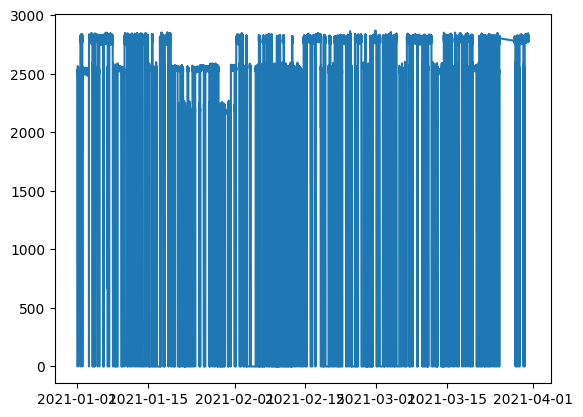

In [5]:
plt.plot(training_df["water_circ_flow"])

In [ ]:
plt

In [5]:
training_df.columns

Index(['charge', 'coupler_position', 'pump_calculated_flow',
       'pump_pressure_diff', 'pump_rotspeed', 'turbine_pressure',
       'turbine_rotspeed', 'water_opening_sum', 'injector_opening_sum',
       'tot_activepower', 'ext_tmp', 'plant_tmp', 'tot_current',
       'tot_effectivepower', 'tot_reactivepower', 'air_circ_cold_01_tmp',
       'air_circ_cold_02_tmp', 'air_circ_cold_03_tmp', 'air_circ_cold_04_tmp',
       'air_circ_cold_05_tmp', 'air_circ_cold_06_tmp', 'air_circ_hot_01_tmp',
       'air_circ_hot_02_tmp', 'air_circ_hot_03_tmp', 'air_circ_hot_04_tmp',
       'air_circ_hot_05_tmp', 'air_circ_hot_06_tmp', 'elec_freq',
       'exc_current', 'exc_voltage', 'mid_voltage', 'neutral_current',
       'ph01_current', 'ph01_voltage', 'ph12_voltage', 'ph02_current',
       'ph02_voltage', 'ph23_voltage', 'ph03_current', 'ph03_voltage',
       'ph31_voltage', 'stat_coil_ph01_01_tmp', 'stat_coil_ph01_02_tmp',
       'stat_coil_ph01_03_tmp', 'stat_coil_ph01_04_tmp',
       'stat_coil_ph

In [6]:
# Define the column groups
groups = {
    'stat_coil': [col for col in training_df.columns if col.startswith('stat_coil')],
    'stat_magn': [col for col in training_df.columns if col.startswith('stat_magn')],
    'air_circ_hot': [col for col in training_df.columns if col.startswith('air_circ_hot')],
    'air_circ_cold': [col for col in training_df.columns if col.startswith('air_circ_cold')],
}

# Define the reference thresholds for minimal and maximal values
thresholds = {
    'stat_coil': {'max': 103},  # Example thresholds
    'stat_magn': {'max': 100},
    'air_circ_hot': {'max': 72},
    'air_circ_cold': {'max': 35},
}

# Initialize a boolean series with False values
boolean_series = pd.Series(False, index=training_df.index)

# Iterate through each group and apply the thresholds
for group, columns in groups.items():
    max_threshold = thresholds[group]['max']
    
    # Compare values with thresholds
    out_of_bounds = (training_df[columns] > max_threshold)
    
    # Update the boolean series if any value in the group is out of bounds
    boolean_series = boolean_series | out_of_bounds.any(axis=1)

# boolean_series now contains True for rows where any value in the groups is outside the thresholds
print(boolean_series)

2021-01-01 00:00:00+01:00    False
2021-01-01 00:00:30+01:00    False
2021-01-01 00:01:00+01:00    False
2021-01-01 00:01:30+01:00    False
2021-01-01 00:02:00+01:00    False
                             ...  
2021-03-30 23:58:00+02:00    False
2021-03-30 23:58:30+02:00    False
2021-03-30 23:59:00+02:00    False
2021-03-30 23:59:30+02:00    False
2021-03-31 00:00:00+02:00    False
Length: 247643, dtype: bool


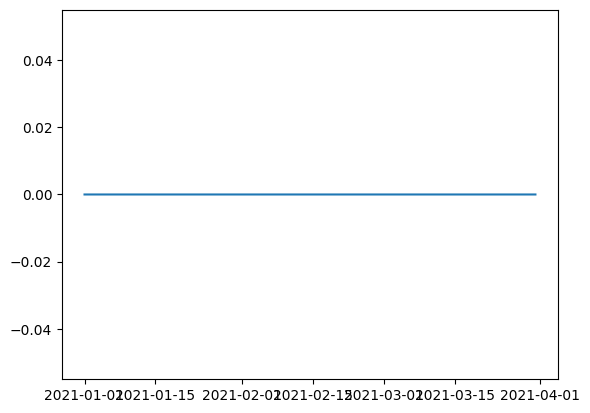

In [7]:
plt.plot(boolean_series)

In [8]:
training_df = training_df[::10]

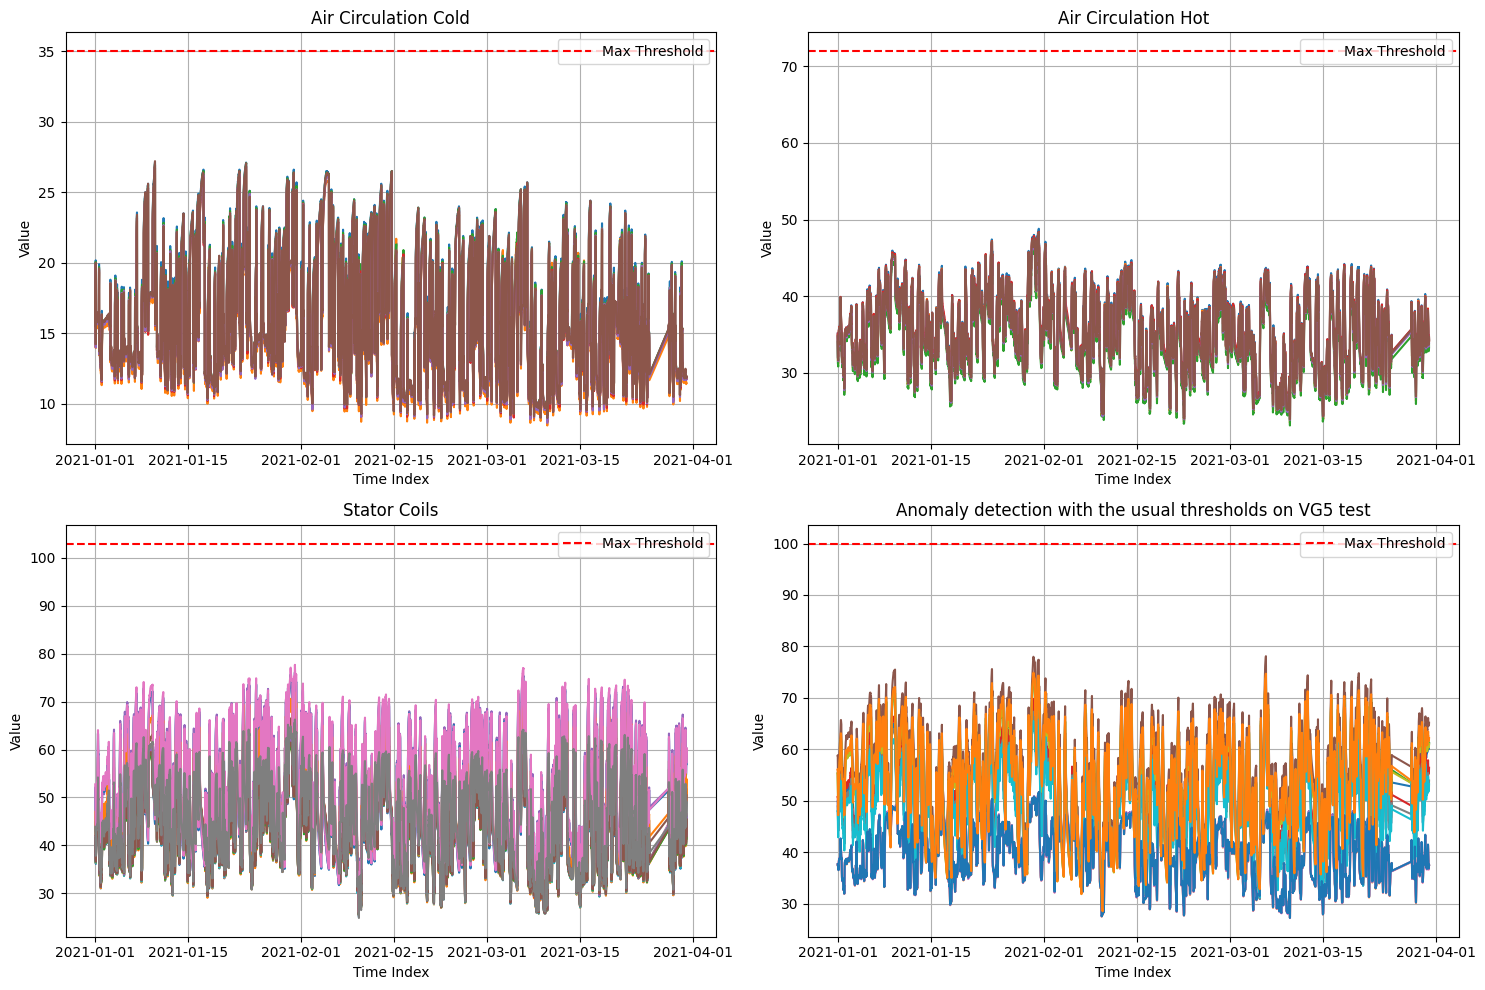

In [11]:
# Create a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Plot for air_circ_cold group
for column in groups["air_circ_cold"]:
    axs[0, 0].plot(training_df[column]#, label=column
    )

axs[0, 0].axhline(thresholds["air_circ_cold"]['max'], color='red', linestyle='--', label='Max Threshold')
axs[0, 0].set_title('Air Circulation Cold')
axs[0, 0].set_xlabel('Time Index')
axs[0, 0].set_ylabel('Value')
axs[0, 0].legend(loc='upper right')
axs[0, 0].grid(True)

# Plot for air_circ_hot group
for column in groups["air_circ_hot"]:
    axs[0, 1].plot(training_df[column]#, label=column
                   )

axs[0, 1].axhline(thresholds["air_circ_hot"]['max'], color='red', linestyle='--', label='Max Threshold')
axs[0, 1].set_title('Air Circulation Hot')
axs[0, 1].set_xlabel('Time Index')
axs[0, 1].set_ylabel('Value')
axs[0, 1].legend(loc='upper right')
axs[0, 1].grid(True)

# Plot for stat_coil group
for column in groups["stat_coil"]:
    axs[1, 0].plot(training_df[column]#, label=column
                   )

axs[1, 0].axhline(thresholds["stat_coil"]['max'], color='red', linestyle='--', label='Max Threshold')
axs[1, 0].set_title('Stator Coils')
axs[1, 0].set_xlabel('Time Index')
axs[1, 0].set_ylabel('Value')
axs[1, 0].legend(loc='upper right')
axs[1, 0].grid(True)

# Plot for stat_magn group
for column in groups["stat_magn"]:
    axs[1, 1].plot(training_df[column]#, label=column
                   )

axs[1, 1].axhline(thresholds["stat_magn"]['max'], color='red', linestyle='--', label='Max Threshold')
axs[1, 1].set_title('Stator Magnets')
axs[1, 1].set_xlabel('Time Index')
axs[1, 1].set_ylabel('Value')
axs[1, 1].legend(loc='upper right')
axs[1, 1].grid(True)

plt.title("Anomaly detection with the usual thresholds on VG5 test")
# Adjust layout
plt.tight_layout()
plt.savefig("../images/usual_alarm_level_VG5_test.pdf")
plt.show()
